# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Данные

Выберу корпус [Obesity Levels](https://www.kaggle.com/datasets/fatemehmehrparvar/obesity-levels):

This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. The data contains 17 attributes and 2111 records, the records are labeled with the class variable NObesity (Obesity Level), that allows classification of the data using the values of Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III. 77% of the data was generated synthetically using the Weka tool and the SMOTE filter, 23% of the data was collected directly from users through a web platform.

Gender: Feature, Categorical, "Gender"  
Age : Feature, Continuous, "Age"  
Height: Feature, Continuous  
Weight: Feature Continuous  
family_history_with_overweight: Feature, Binary, " Has a family member suffered or suffers from overweight? "

FAVC : Feature, Binary, " Do you eat high caloric food frequently? "  
FCVC : Feature, Integer, " Do you usually eat vegetables in your meals? "  
NCP : Feature, Continuous, " How many main meals do you have daily? "  
CAEC : Feature, Categorical, " Do you eat any food between meals? "  
SMOKE : Feature, Binary, " Do you smoke? "  
CH2O: Feature, Continuous, " How much water do you drink daily? "  
SCC: Feature, Binary, " Do you monitor the calories you eat daily? "  
FAF: Feature, Continuous, " How often do you have physical activity? "  
TUE : Feature, Integer, " How much time do you use technological devices such as cell phone, videogames, television, computer and others? "

CALC : Feature, Categorical, " How often do you drink alcohol? "  
MTRANS : Feature, Categorical, " Which transportation do you usually use? "  
NObeyesdad : Target, Categorical, "Obesity level"

In [2]:
import kagglehub


kagglehub.dataset_download(
    "fatemehmehrparvar/obesity-levels", output_dir="./data", force_download=True
)

path = "data/ObesityDataSet_raw_and_data_sinthetic.csv"

/Users/pinta/Dev/mlStart/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 57.6k/57.6k [00:00<00:00, 578kB/s]

Extracting files...


In [3]:
df = pd.read_csv(path)

In [4]:
df.shape

(2111, 17)

In [5]:
df.columns.tolist()

['Age',
 'Gender',
 'Height',
 'Weight',
 'CALC',
 'FAVC',
 'FCVC',
 'NCP',
 'SCC',
 'SMOKE',
 'CH2O',
 'family_history_with_overweight',
 'FAF',
 'TUE',
 'CAEC',
 'MTRANS',
 'NObeyesdad']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   str    
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   str    
 12  FAF                             2111 non-null

In [7]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [8]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


Значения признаков находятся в правдоподобных диапазонах, явных ошибок на первичном просмотре (вроде как) нет.  


In [9]:
df.isnull().sum()

Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Пропущенных значений нет, заполнять данные не требуется.


In [10]:
df.drop_duplicates(inplace=True)

df.shape

(2087, 17)

Было удалено $2111 - 2087 = 24$ полных дубликата.


In [11]:
features = df.columns.to_list()
numerical_features = df.select_dtypes("float64").columns.to_list()
str_features = df.select_dtypes("str").columns.to_list()

target = "NObeyesdad"
target_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

print(
    f"{len(numerical_features)} числовых (мб часть из них -- конечномерные) и {len(str_features)} категориальных признаков"
)
numerical_features, str_features

8 числовых (мб часть из них -- конечномерные) и 9 категориальных признаков


(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'],
 ['Gender',
  'CALC',
  'FAVC',
  'SCC',
  'SMOKE',
  'family_history_with_overweight',
  'CAEC',
  'MTRANS',
  'NObeyesdad'])

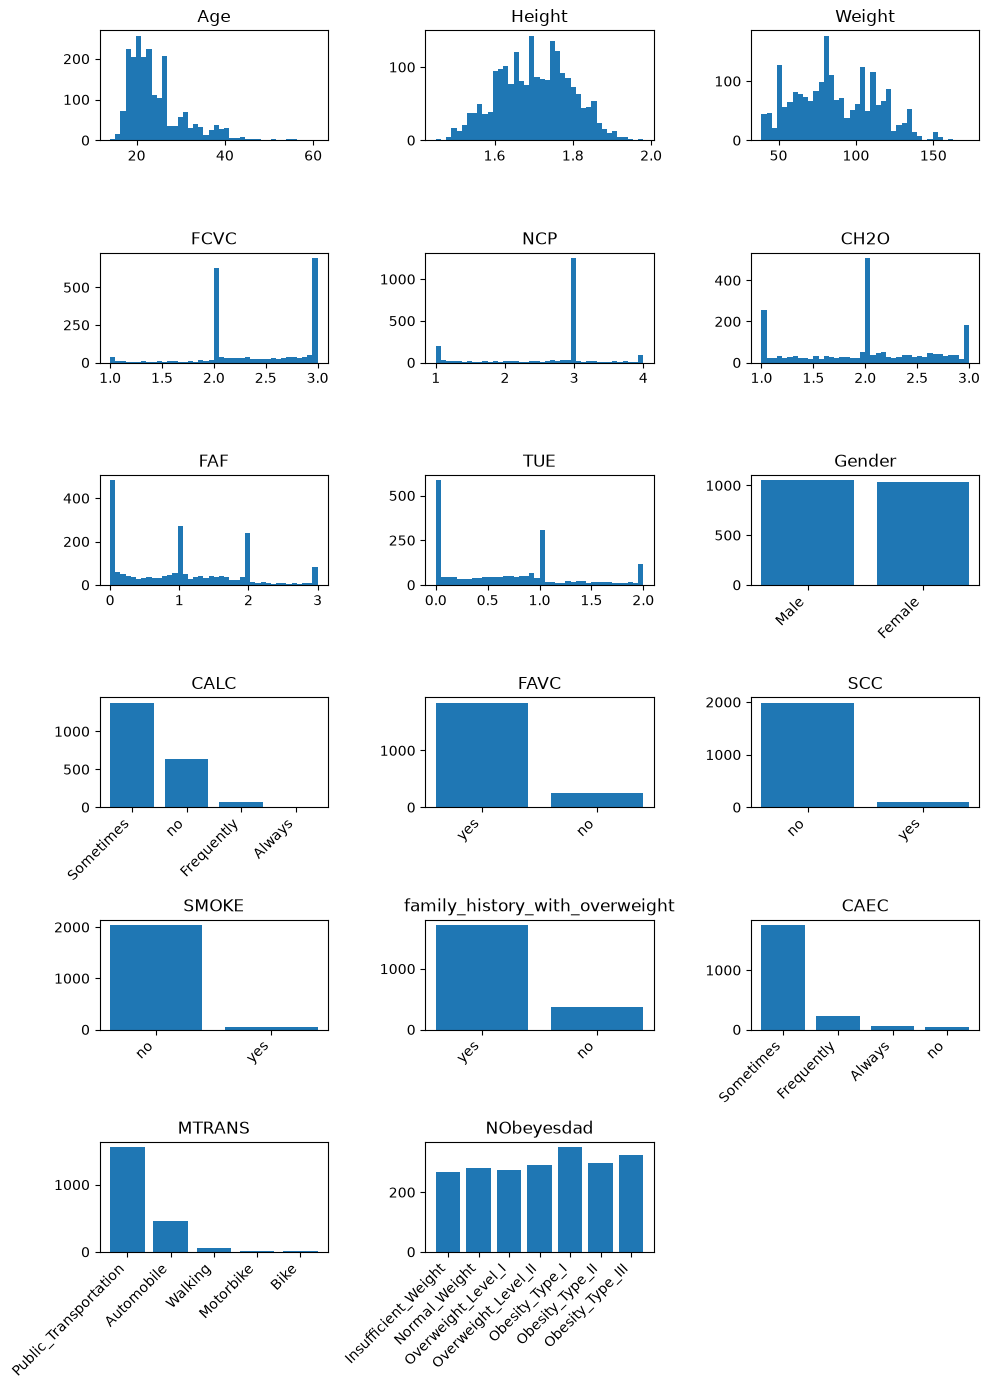

In [12]:
nrows, ncols = 6, 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 14))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].hist(df[feature], bins=40)
    axes[i].set_title(feature)

for j, feature in enumerate(str_features):
    j = len(numerical_features) + j

    counts = df[feature].value_counts()
    if feature == target:
        counts = counts.reindex(target_order)

    axes[j].bar(counts.index, counts.values)
    axes[j].set_title(feature)
    axes[j].set_xticks(
        np.arange(len(counts)), labels=counts.index, rotation=45, ha="right"
    )

for k in range(len(features), nrows * ncols):
    axes[k].set_visible(False)

fig.tight_layout()
plt.show()

Целевой класс представлен примерно равномерно, поэтому выраженного дисбаланса нет.  
У признаков `FCVC`, `NCP`, `CH2O`, `FAF` и `TUE` заметны пики около отдельных значений: по смыслу они ближе к ограниченным шкалам, чем к обычным непрерывным признакам. Некоторые категории (`SMOKE`, `SCC`, отдельные варианты `CALC` и `MTRANS`) встречаются редко.


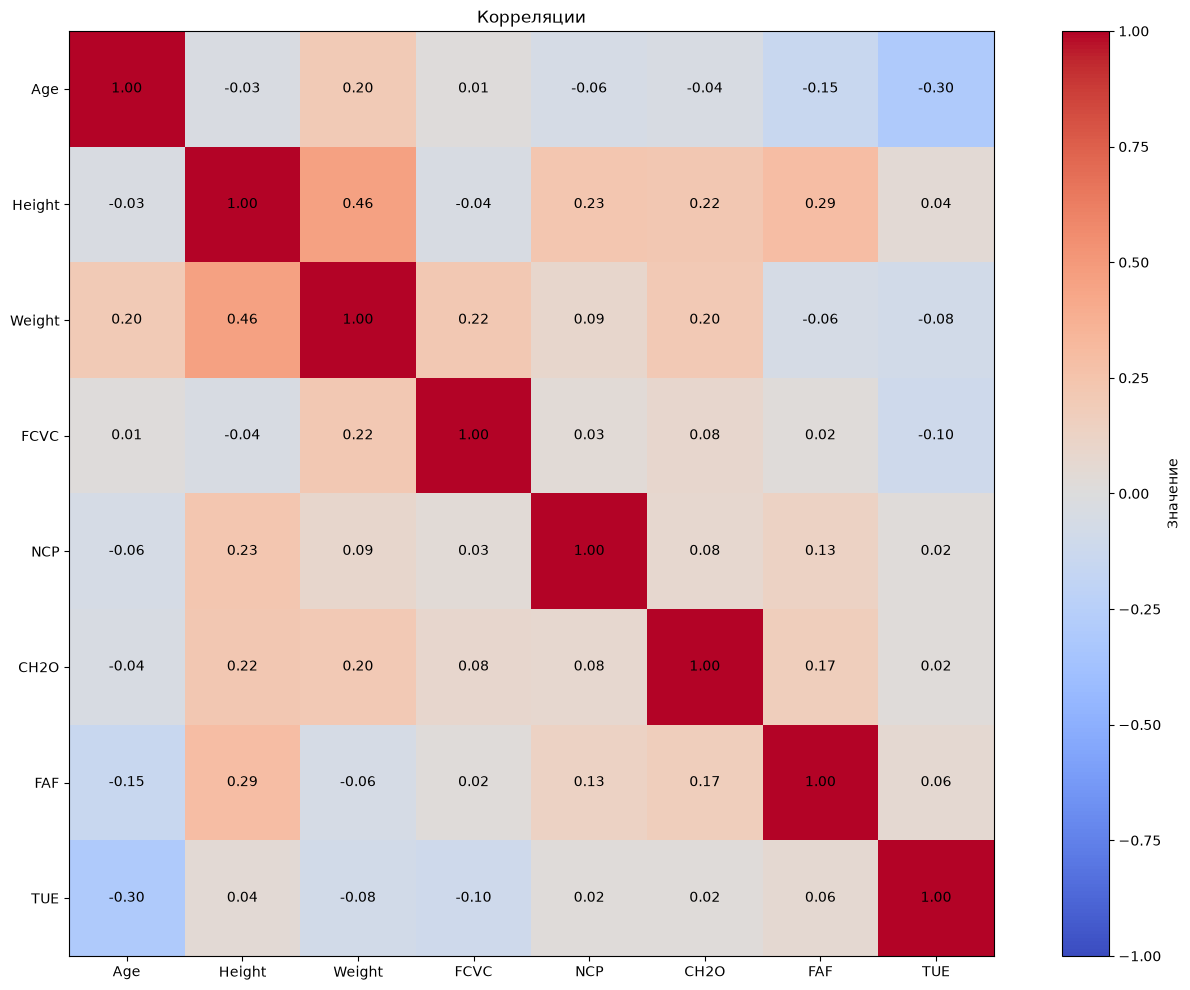

In [13]:
corr_matrix = df[numerical_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(j, i, f"{corr_matrix.iat[i, j]:.2f}", ha="center", va="center")

ax.set_xticks(np.arange(len(numerical_features)))
ax.set_yticks(np.arange(len(numerical_features)))
ax.set_xticklabels(numerical_features)
ax.set_yticklabels(numerical_features)
ax.set_title("Корреляции")
fig.colorbar(im, ax=ax, label="Значение")
fig.tight_layout()

plt.show()

Сильной линейной зависимости между числовыми признаками нет. Наиболее заметна связь роста с весом; более слабые связи наблюдаются у роста с `NCP` и `FAF`, а также у возраста с `TUE`.  
Выраженной мультиколлинеарности не обнаружено.


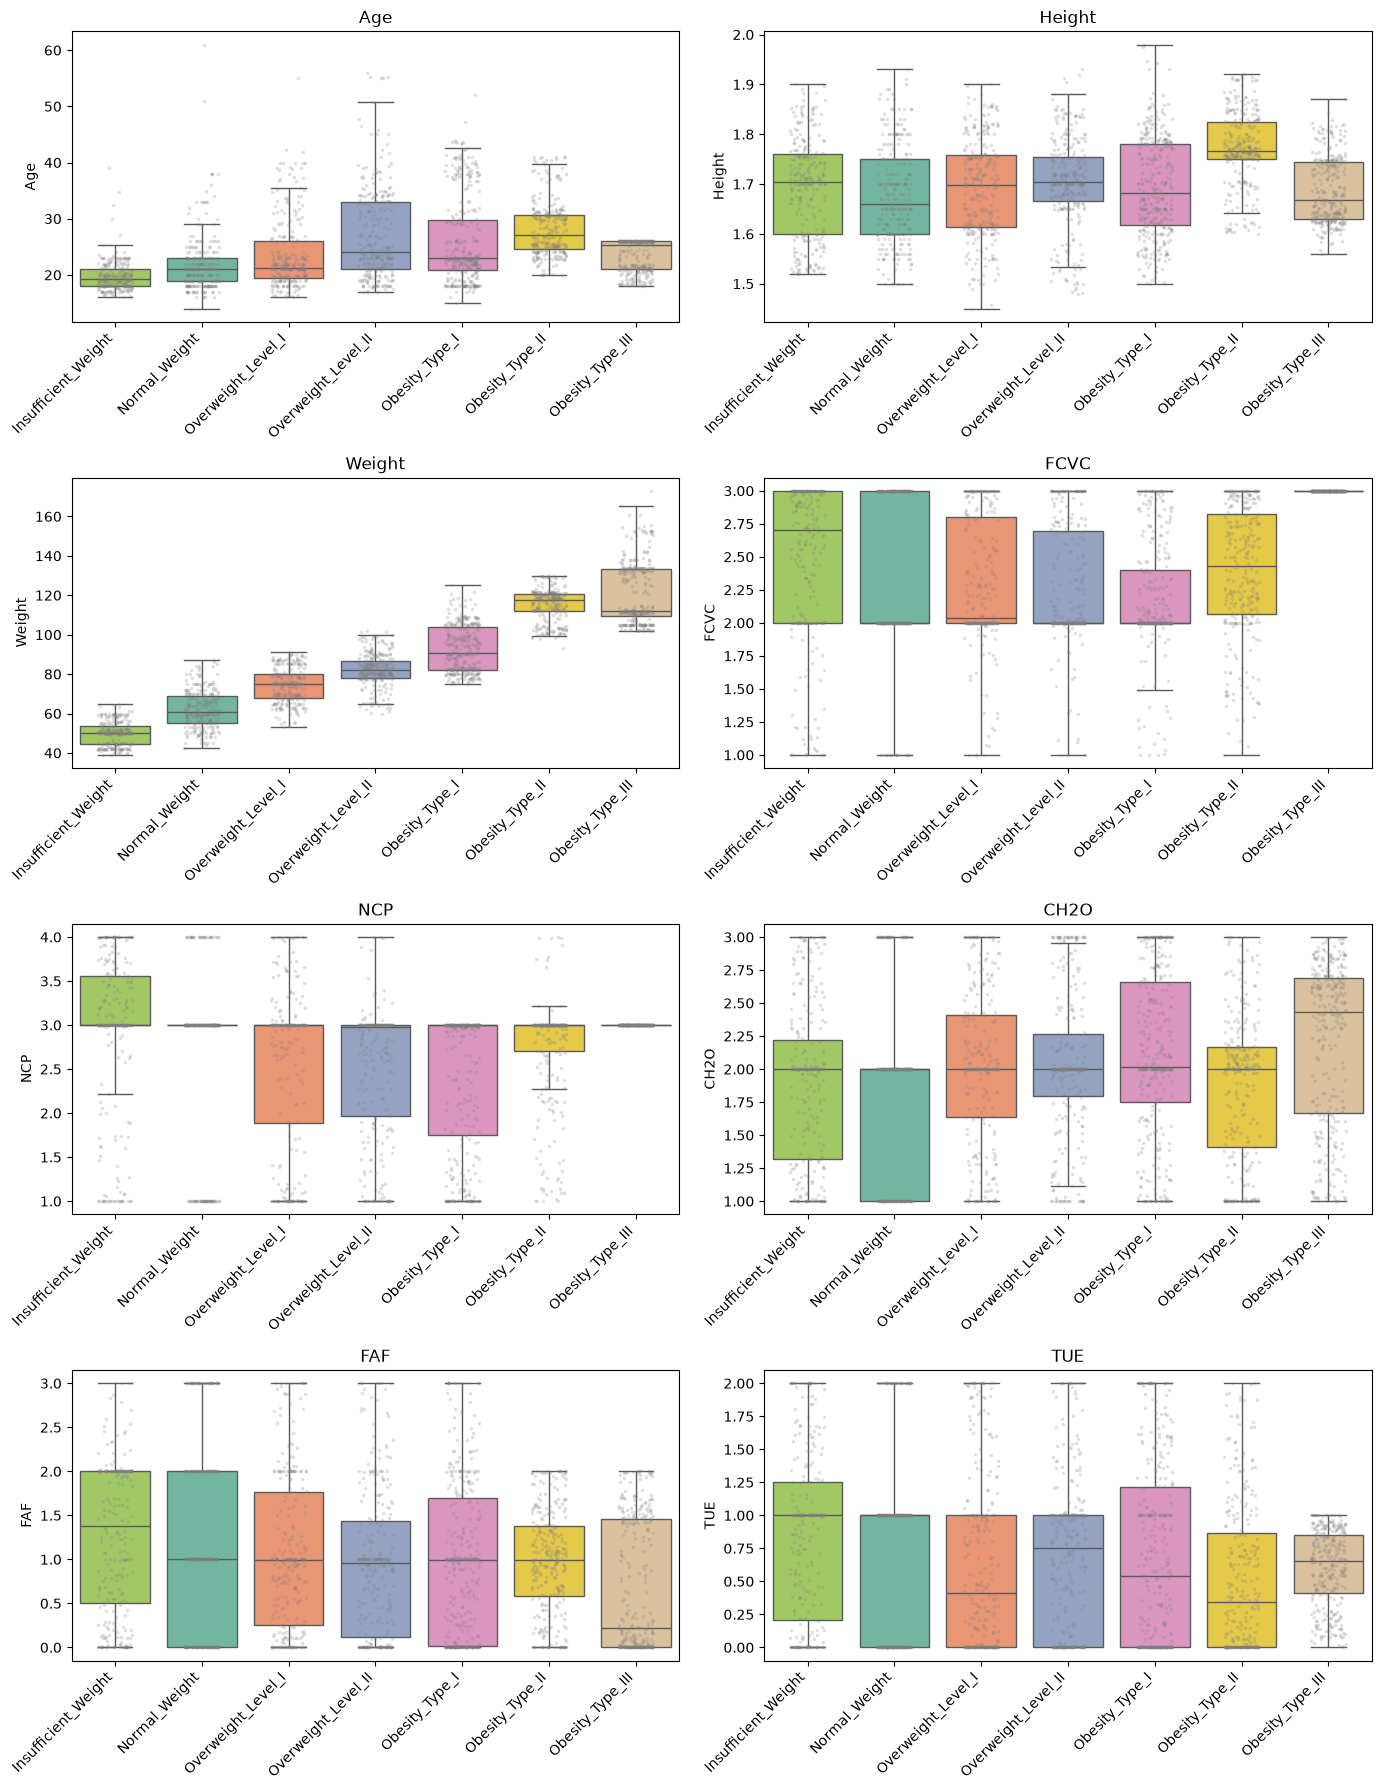

In [17]:
nrows, ncols = 4, 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 18))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        data=df,
        x=target,
        y=feature,
        order=target_order,
        hue=target,
        palette="Set2",
        dodge=False,
        legend=False,
        showfliers=False,
        ax=axes[i],
    )

    sns.stripplot(
        data=df,
        x=target,
        y=feature,
        order=target_order,
        color="gray",
        size=2.5,
        alpha=0.25,
        jitter=0.2,
        linewidth=0,
        zorder=3,
        ax=axes[i],
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)
    plt.setp(axes[i].get_xticklabels(), ha="right")

fig.tight_layout()
plt.show()

Вес разделяет классы заметно лучше остальных числовых признаков (с точки зрения логики вполне объяснимо); поведенческие признаки по отдельности разделяют классы слабее.

Видны некие выбросы, но они не столь ужасны, плюс есть предположение, что для обучения модели лучшего качества их лучше бы сохранить...


Ранее была обнаружена некая корреляция роста и веса, рассмотрю подробнее ее:

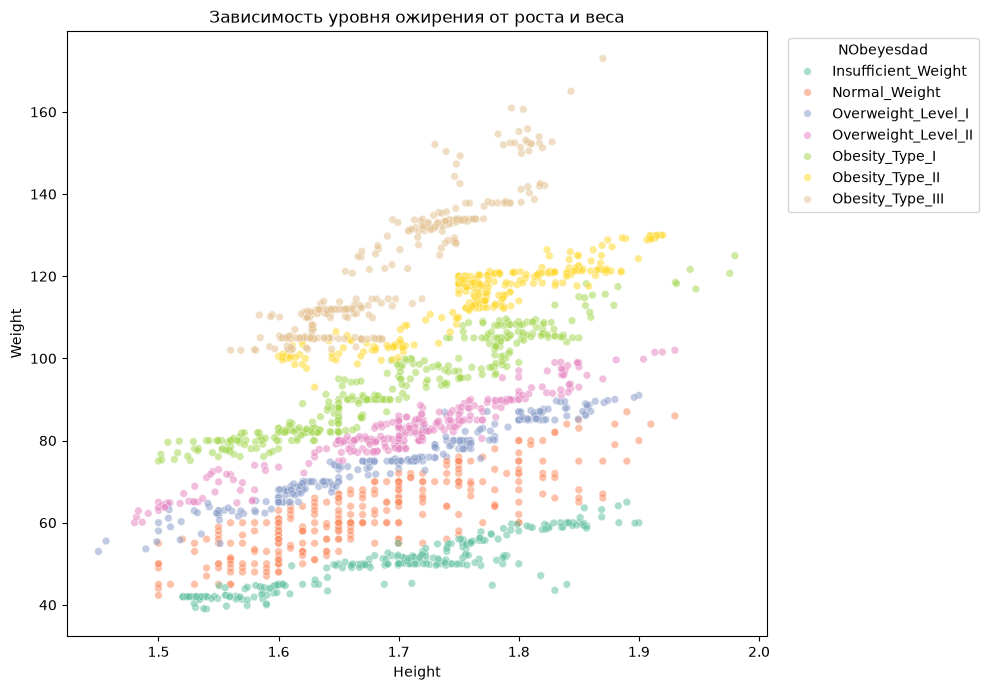

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Height",
    y="Weight",
    hue=target,
    hue_order=target_order,
    palette="Set2",
    alpha=0.55,
    s=30,
    ax=ax,
)

ax.set_title("Зависимость уровня ожирения от роста и веса")
ax.set_xlabel("Height")
ax.set_ylabel("Weight")
ax.legend(title=target, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

При сопоставимом росте увеличение веса в целом соответствует переходу к более высоким уровням ожирения.  
Совместно рост и вес разделяют классы значительно лучше, чем каждый из этих признаков по отдельности, мб стоит на них либо полиномиал фичерс натравить, либо добавить в признаковое пространство что-то типа ИМТ...


Остальные совместные распределения посмотрим:


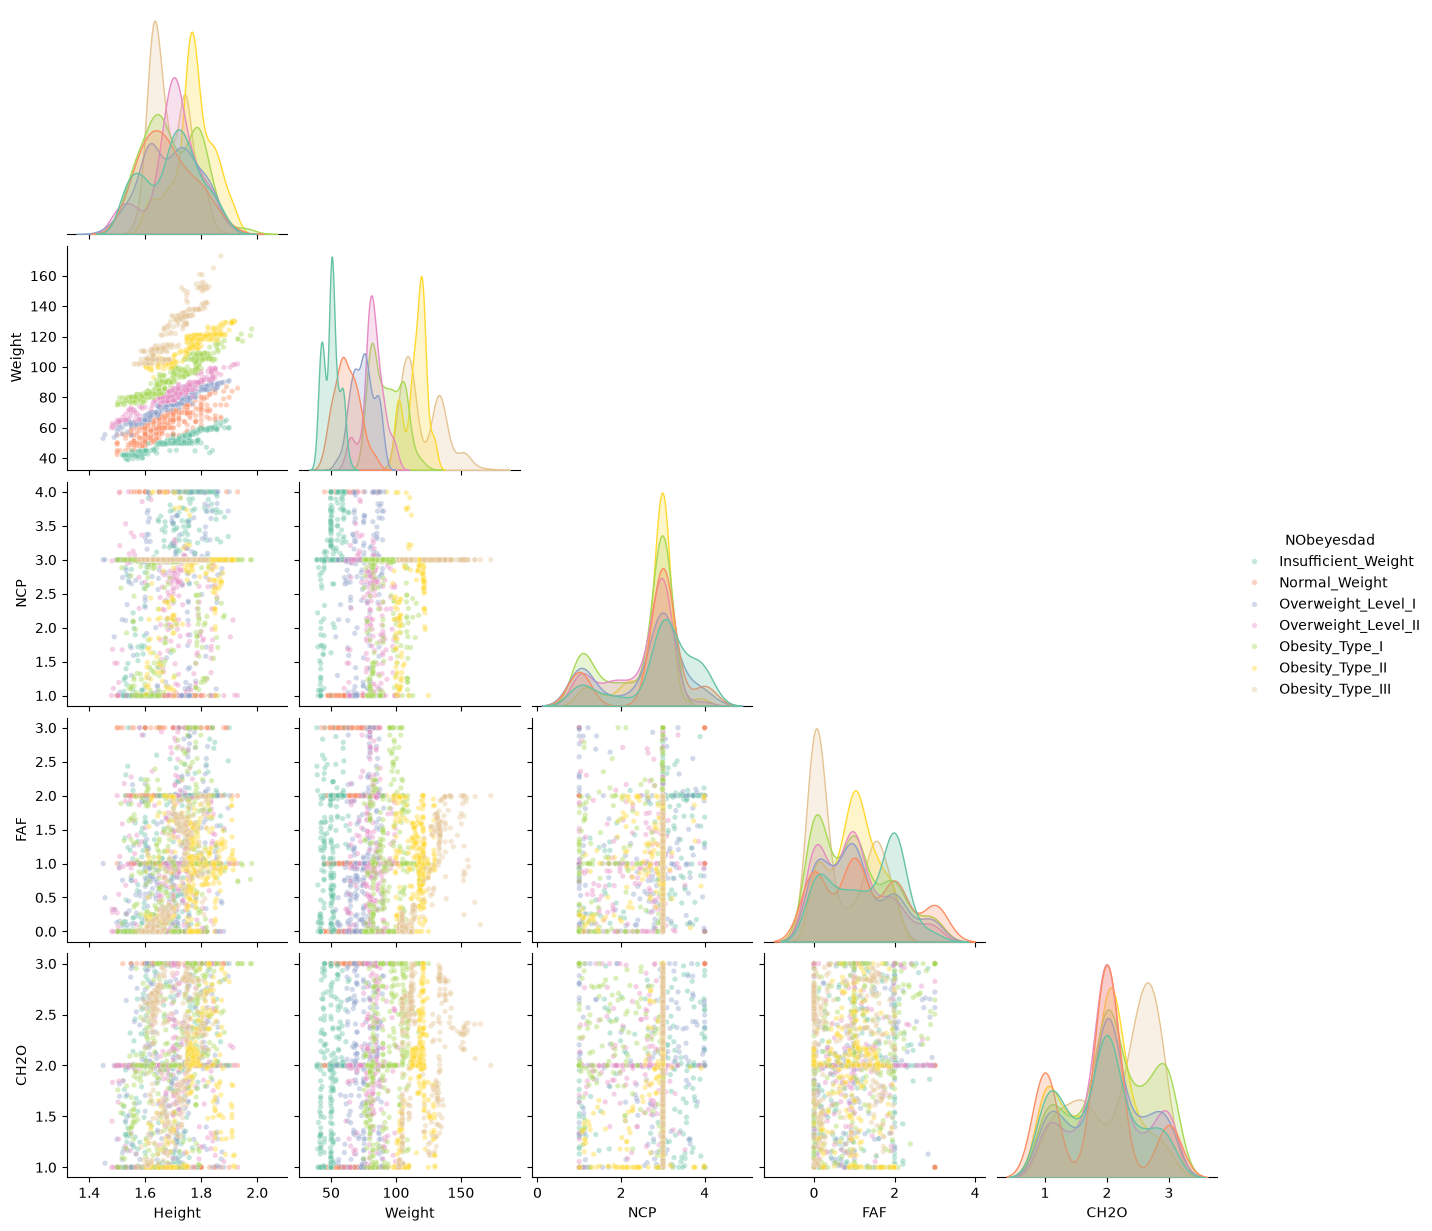

In [16]:
sns.pairplot(
    df[["Height", "Weight", "NCP", "FAF", "CH2O", target]],
    hue=target,
    hue_order=target_order,
    palette="Set2",
    corner=True,
    plot_kws={"alpha": 0.4, "s": 15},
)
plt.show()

Дополнительных явных линейных зависимостей не наблюдаю.
